# Linear Support Vector Classifier

In [2]:
# Load Iris dataset
import numpy as np
import pandas as pd
from sklearn import datasets

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
# Select Setosa and Versicolor only and petal length and petal width only
df2 = df.iloc[:100, 2:].copy()
df2.tail()

,petal length (cm),petal width (cm),target
95,4.2,1.2,1
96,4.2,1.3,1
97,4.3,1.3,1
98,3.0,1.1,1
99,4.1,1.3,1


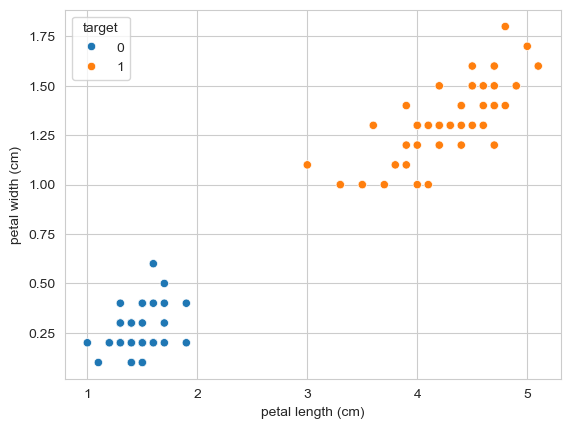

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Plot Sepal Length vs Sepal Width
sns.scatterplot(x ='petal length (cm)', y ='petal width (cm)', data = df2, hue ='target');

In [6]:
X = df2.iloc[:,:-1].values
y = df2.iloc[:, -1].values

In [7]:
# Split the dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [8]:
# Linear SVM    
from sklearn.svm import SVC
svm = SVC(kernel = 'linear', random_state = 0)
svm.fit(X_train, y_train)

# coefficients
svm.intercept_, svm.coef_

(array([-3.27499998]), array([[1.1, 0.7]]))

In [9]:
decision = svm.intercept_[0] + svm.coef_[0][0] * X_test[5][0] + svm.coef_[0][1] * X_test[5][1] 
decision

1.055000023841858

In [16]:
svm.decision_function(X_test[[5]])

array([-1.23499998])

In [19]:
svm.predict(X_test[5, :] .reshape(1, -1))

array([1])

In [10]:
svm.support_vectors_

array([[1.9, 0.4],
       [3. , 1.1]])

In [11]:
# Plot the decision boundary
def plot_decision_boundary(xmin, xmax, svc):
    x0 = np.linspace(xmin, xmax, 100)
    b = svc.intercept_[0]
    w0 = svc.coef_[0][0]
    w1 = svc.coef_[0][1]
    boundary = -(w0 * x0 + b) / w1
    margin1 = -(w0 * x0 + b + 1) / w1
    margin2 = -(w0 * x0 + b - 1) / w1
    support_vectors = svc.support_vectors_

    # Plot the decision boundary
    plt.plot(x0, boundary, 'k-');
    
    # Plot the support vectors
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s = 100, facecolors = 'none', edgecolors = 'k');

    # plot the margin lines
    plt.plot(x0, margin1, 'k--')
    plt.plot(x0, margin2, 'k--');

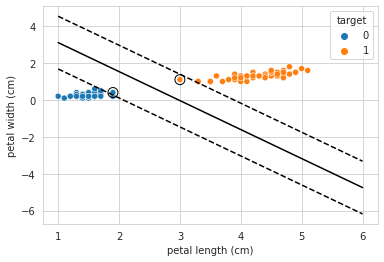

In [12]:
sns.scatterplot(x ='petal length (cm)', y ='petal width (cm)', data = df2, hue ='target')
plot_decision_boundary(1, 6, svm);

In [13]:
X_test[5, :]

array([3.3, 1. ])

In [14]:
svm.predict(X_test[5, :] .reshape(1, -1))

array([1])

In [15]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Linear SVM
svm2 = SVC(kernel = 'linear', random_state = 0)
svm2.fit(X_train, y_train)


SVC(kernel='linear', random_state=0)

In [16]:
svm2.intercept_, svm2.coef_

(array([0.33189111]), array([[1.04472658, 0.94015577]]))

In [17]:
svm2.support_vectors_

array([[-0.88198307, -0.33685084],
       [-0.81219212, -0.51414076],
       [ 0.304463  ,  0.37230883],
       [ 0.09509016,  0.54959874]])

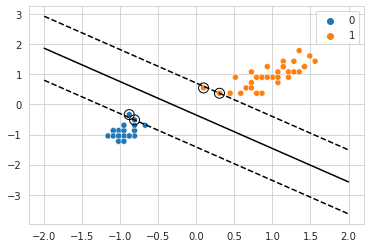

In [18]:
sns.scatterplot(x = X_train[:, 0], y = X_train[:, 1], hue = y_train)
plot_decision_boundary(-2, 2, svm2);